In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection      import train_test_split, GridSearchCV
from sklearn.preprocessing        import StandardScaler
from sklearn.linear_model         import LogisticRegression
from sklearn.ensemble             import RandomForestClassifier
from sklearn.dummy                import DummyClassifier
from sklearn.metrics              import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score
)
from imblearn.pipeline            import Pipeline
from imblearn.over_sampling       import SMOTE, RandomOverSampler
from imblearn.under_sampling      import RandomUnderSampler

In [33]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

In [34]:
DATA_PATH        = "creditcard.csv"
TARGET_COLUMN    = "Class"            # 0 = Legitimate, 1 = Fraudulent
TEST_SIZE        = 0.20              # 80/20 split
RANDOM_STATE     = 42
CV_FOLDS         = 5                 # 5-fold cross validation
ROC_AUC_TARGET   = 0.85             # minimum acceptable ROC-AUC

In [35]:
print("=" * 60)
print("STEP 1: LOADING DATASET")
print("=" * 60)

STEP 1: LOADING DATASET


In [36]:
df = pd.read_csv(DATA_PATH)
print(f"\nDataset shape : {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Columns : {list(df.columns)}")


Dataset shape : 284,807 rows x 31 columns
Columns : ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


In [37]:
print(f"\n[INFO] Data Types:")
print(df.dtypes)


[INFO] Data Types:
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object


In [38]:
print(f"\nStatistical Summary:")
df.describe()


Statistical Summary:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [39]:
print(f"\nMissing Values: {df.isnull().sum().sum()}")


Missing Values: 0


In [40]:
print("\n" + "=" * 60)
print("STEP 2: CLASS IMBALANCE VISUALIZATION")
print("=" * 60)


STEP 2: CLASS IMBALANCE VISUALIZATION


In [41]:
fraud_counts = df[TARGET_COLUMN].value_counts().sort_index()
fraud_pct    = df[TARGET_COLUMN].value_counts(normalize=True).sort_index() * 100

# Extract values safely by position after sorting
n_legit    = int(fraud_counts.iloc[0])
n_fraud    = int(fraud_counts.iloc[1])
pct_legit  = float(fraud_pct.iloc[0])
pct_fraud  = float(fraud_pct.iloc[1])

print(f"\n[INFO] Legitimate transactions : {n_legit:,}  ({pct_legit:.2f}%)")
print(f"[INFO] Fraudulent transactions : {n_fraud:,}  ({pct_fraud:.2f}%)")
print(f"[INFO] Imbalance ratio         : {n_legit/n_fraud:.0f}:1")


[INFO] Legitimate transactions : 284,315  (99.83%)
[INFO] Fraudulent transactions : 492  (0.17%)
[INFO] Imbalance ratio         : 578:1


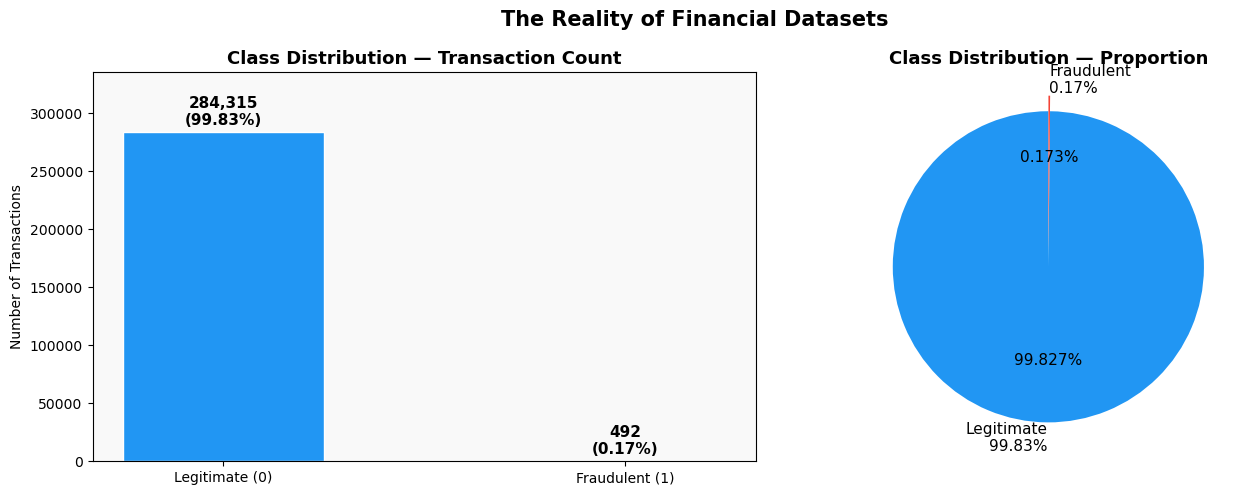

[SAVED] 01_class_imbalance.png


In [42]:
colors = ['#2196F3', '#F44336']
labels = ['Legitimate (0)', 'Fraudulent (1)']
counts = [n_legit, n_fraud]
pcts   = [pct_legit, pct_fraud]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
bars = axes[0].bar(labels, counts, color=colors, edgecolor='white', width=0.5)
for bar, count, pct in zip(bars, counts, pcts):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + n_legit * 0.01,
        f'{count:,}\n({pct:.2f}%)',
        ha='center', va='bottom', fontsize=11, fontweight='bold'
    )
axes[0].set_title('Class Distribution — Transaction Count', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Transactions')
axes[0].set_ylim(0, n_legit * 1.18)
axes[0].set_facecolor('#f9f9f9')

# Pie chart
pie_labels = [f'Legitimate\n{pct_legit:.2f}%', f'Fraudulent\n{pct_fraud:.2f}%']
axes[1].pie(
    counts,
    labels=pie_labels,
    colors=colors,
    autopct='%1.3f%%',
    startangle=90,
    explode=(0, 0.1),
    textprops={'fontsize': 11}
)
axes[1].set_title('Class Distribution — Proportion', fontsize=13, fontweight='bold')

plt.suptitle('The Reality of Financial Datasets', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('01_class_imbalance.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print("[SAVED] 01_class_imbalance.png")

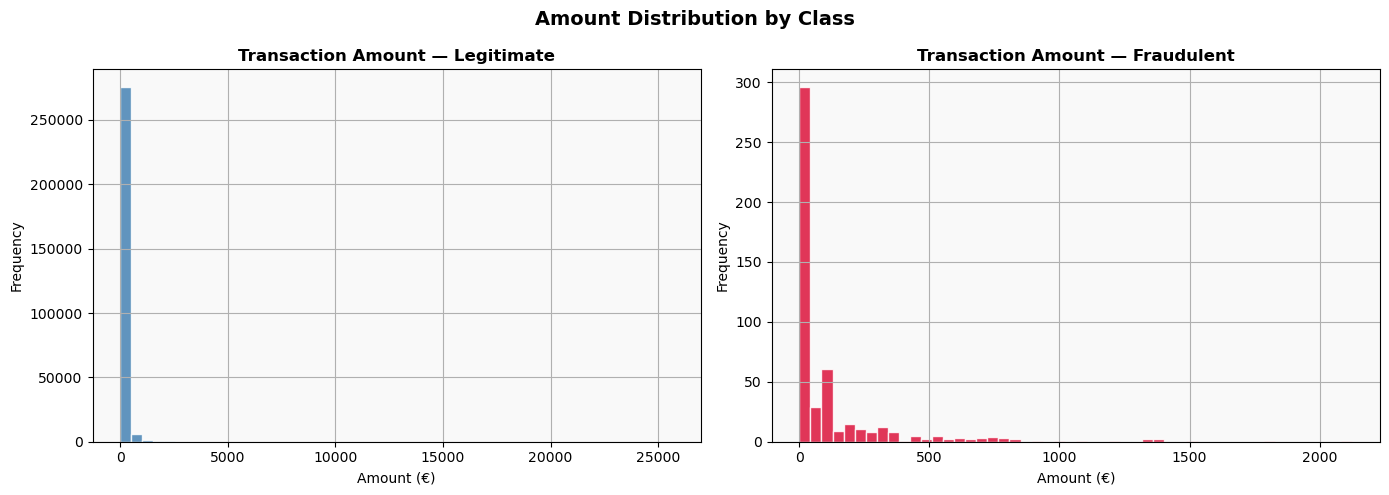

[SAVED] 02_amount_distribution.png


In [43]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df[df[TARGET_COLUMN] == 0]['Amount'].hist(
    bins=50, ax=axes[0], color='steelblue', edgecolor='white', alpha=0.85
)
axes[0].set_title('Transaction Amount — Legitimate', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Amount (€)')
axes[0].set_ylabel('Frequency')
axes[0].set_facecolor('#f9f9f9')

df[df[TARGET_COLUMN] == 1]['Amount'].hist(
    bins=50, ax=axes[1], color='crimson', edgecolor='white', alpha=0.85
)
axes[1].set_title('Transaction Amount — Fraudulent', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Amount (€)')
axes[1].set_ylabel('Frequency')
axes[1].set_facecolor('#f9f9f9')

plt.suptitle('Amount Distribution by Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('02_amount_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print("[SAVED] 02_amount_distribution.png")

In [44]:
print("\n" + "=" * 60)
print("STEP 3: THE ACCURACY TRAP DEMONSTRATION")
print("=" * 60)


STEP 3: THE ACCURACY TRAP DEMONSTRATION


In [45]:
X = df.drop(TARGET_COLUMN, axis=1)
y = df[TARGET_COLUMN]

# Stratified split FIRST — before any SMOTE or scaling
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"Train size : {X_train.shape[0]:,} rows")
print(f"Test size  : {X_test.shape[0]:,} rows")
print(f"Train fraud rate: {y_train.mean()*100:.3f}%")
print(f"Test fraud rate : {y_test.mean()*100:.3f}%")

Train size : 227,845 rows
Test size  : 56,962 rows
Train fraud rate: 0.173%
Test fraud rate : 0.172%


In [46]:
# Dummy classifier — predicts "Legitimate" every time
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)
dummy_acc = dummy.score(X_test, y_test)

print(f"\n[TRAP] Dummy Classifier (always predicts Legitimate):")
print(f"       Accuracy = {dummy_acc*100:.2f}%  ← looks amazing!")
print(f"       Fraud caught = 0  ← catastrophic financial loss!")
print(f"\n[LESSON] NEVER use Accuracy on imbalanced datasets.")
print(f"         Use Precision, Recall, and ROC-AUC instead.")


[TRAP] Dummy Classifier (always predicts Legitimate):
       Accuracy = 99.83%  ← looks amazing!
       Fraud caught = 0  ← catastrophic financial loss!

[LESSON] NEVER use Accuracy on imbalanced datasets.
         Use Precision, Recall, and ROC-AUC instead.


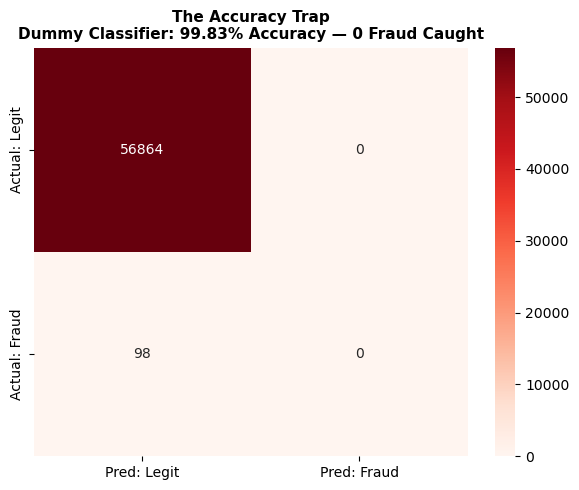

[SAVED] 03_accuracy_trap.png


In [47]:
#accuracy trap confusion matrix
dummy_preds = dummy.predict(X_test)
cm_dummy = confusion_matrix(y_test, dummy_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_dummy, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Pred: Legit', 'Pred: Fraud'],
            yticklabels=['Actual: Legit', 'Actual: Fraud'])
plt.title(f'The Accuracy Trap\nDummy Classifier: {dummy_acc*100:.2f}% Accuracy — 0 Fraud Caught',
          fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('03_accuracy_trap.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print("[SAVED] 03_accuracy_trap.png")

In [48]:
print("\n" + "=" * 60)
print("STEP 4: REBALANCING STRATEGY COMPARISON")
print("=" * 60)


STEP 4: REBALANCING STRATEGY COMPARISON


In [49]:
#Random Undersampling (The Loss)
rus = RandomUnderSampler(random_state=RANDOM_STATE)
X_under, y_under = rus.fit_resample(X_train, y_train)
print(f"\n[UNDERSAMPLING] Result: {dict(pd.Series(y_under).value_counts())}")
print(f"                Rows kept: {len(X_under):,} / {len(X_train):,}")
print(f"                WARNING: Destroyed {len(X_train)-len(X_under):,} legitimate transactions!")


[UNDERSAMPLING] Result: {0: np.int64(394), 1: np.int64(394)}
                Rows kept: 788 / 227,845


In [50]:
#Naive Oversampling (The Echo — just duplicates)
ros = RandomOverSampler(random_state=RANDOM_STATE)
X_over, y_over = ros.fit_resample(X_train, y_train)
print(f"\n[OVERSAMPLING]  Result: {dict(pd.Series(y_over).value_counts())}")
print(f"                Rows created: {len(X_over):,}")
print(f"                WARNING: Just duplicated {y_over.sum()-y_train.sum():,} fraud rows → overfitting!")


[OVERSAMPLING]  Result: {0: np.int64(227451), 1: np.int64(227451)}
                Rows created: 454,902


In [51]:
#SMOTE (The Synthesis — interpolates new points)
smote_demo = SMOTE(random_state=RANDOM_STATE)
X_smote, y_smote = smote_demo.fit_resample(X_train, y_train)
print(f"\n[SMOTE]         Result: {dict(pd.Series(y_smote).value_counts())}")
print(f"                Synthetic samples created: {y_smote.sum()-y_train.sum():,}")
print(f"                Formula: x_new = x_i + λ × (x_nn - x_i)  where λ ~ Uniform(0,1)")
print(f"                CORRECT: Interpolates new points, not clones!")


[SMOTE]         Result: {0: np.int64(227451), 1: np.int64(227451)}
                Synthetic samples created: 227,057
                Formula: x_new = x_i + λ × (x_nn - x_i)  where λ ~ Uniform(0,1)
                CORRECT: Interpolates new points, not clones!


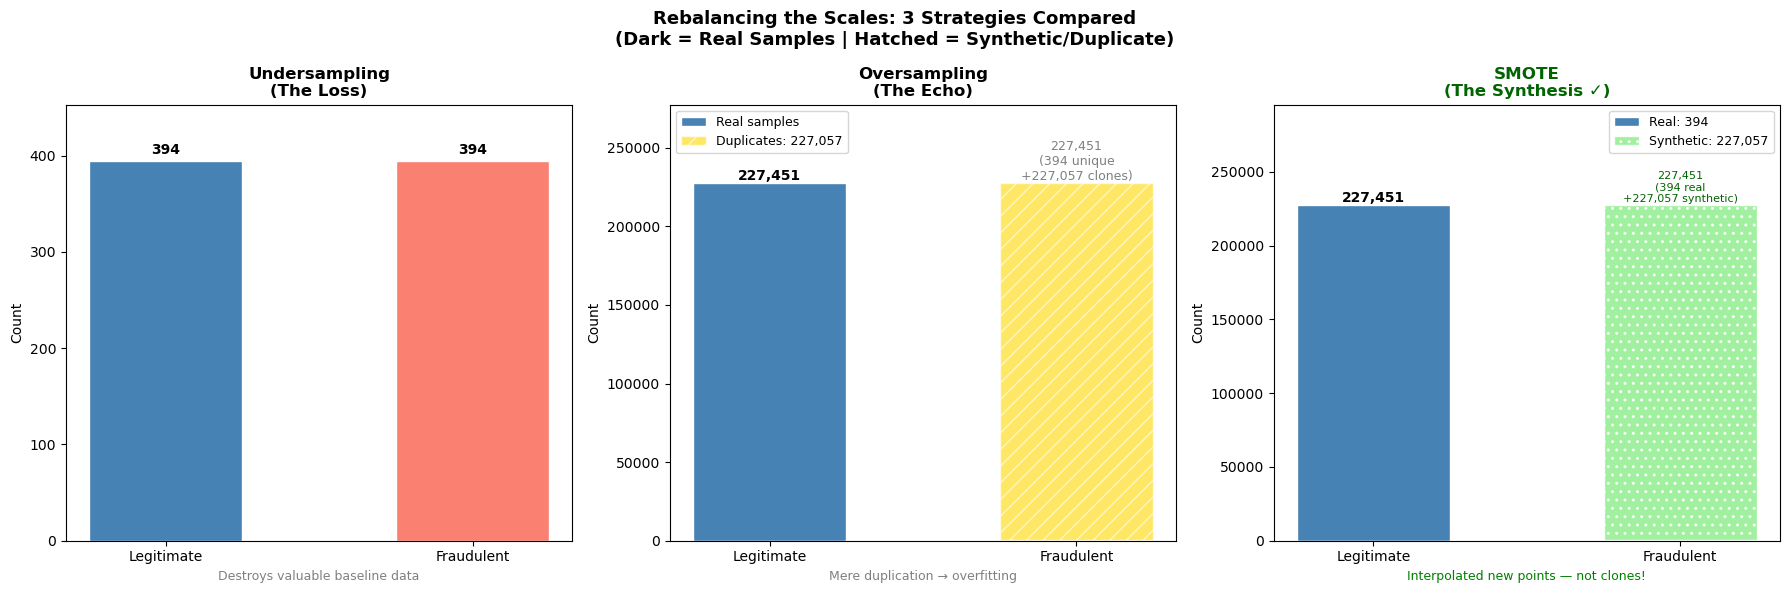

[SAVED] 04_rebalancing_comparison.png


In [52]:
import matplotlib.pyplot as plt
import pandas as pd

#3 strategies side-by-side
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

#Original counts before any resampling
n_legit_orig  = int((y_train == 0).sum())
n_fraud_orig  = int((y_train == 1).sum())

#Undersampling
counts_under = pd.Series(y_under).value_counts().sort_index()
axes[0].bar(['Legitimate', 'Fraudulent'], counts_under.values,
            color=['steelblue', 'salmon'], edgecolor='white', width=0.5)

for i, v in enumerate(counts_under.values):
    axes[0].text(i, v + max(counts_under.values) * 0.02, f'{v:,}', ha='center', fontsize=10, fontweight='bold')

axes[0].set_title('Undersampling\n(The Loss)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Destroys valuable baseline data', fontsize=9, color='gray')
axes[0].set_ylabel('Count')
# Give it a tight, focused Y-limit so the bars fill the frame beautifully
axes[0].set_ylim(0, max(counts_under.values) * 1.15)


#Oversampling
n_over_legit  = int((y_over == 0).sum())
n_over_fraud  = int((y_over == 1).sum())
n_dup_fraud   = n_over_fraud - n_fraud_orig   # duplicated rows

axes[1].bar(['Legitimate', 'Fraudulent'],
            [n_over_legit, n_fraud_orig],
            color=['steelblue', 'gold'], edgecolor='white', width=0.5, label='Real samples')
axes[1].bar(['Legitimate', 'Fraudulent'],
            [0, n_dup_fraud],
            bottom=[0, n_fraud_orig],
            color='#FFD700', edgecolor='white', width=0.5,
            hatch='//', alpha=0.6, label=f'Duplicates: {n_dup_fraud:,}')

axes[1].text(0, n_over_legit + n_over_legit * 0.01, f'{n_over_legit:,}', ha='center', fontsize=10, fontweight='bold')
# Fixed text label to clarify unique vs cloned entries:
axes[1].text(1, n_over_fraud + n_over_legit * 0.01, 
             f'{n_over_fraud:,}\n({n_fraud_orig:,} unique\n+{n_dup_fraud:,} clones)', 
             ha='center', fontsize=9, color='gray')

axes[1].set_title('Oversampling\n(The Echo)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Mere duplication → overfitting', fontsize=9, color='gray')
axes[1].set_ylabel('Count')
axes[1].set_ylim(0, n_over_legit * 1.22)
axes[1].legend(fontsize=9)


#SMOTE
n_smote_legit   = int((y_smote == 0).sum())
n_smote_fraud   = int((y_smote == 1).sum())
n_synthetic     = n_smote_fraud - n_fraud_orig   # new interpolated points

axes[2].bar(['Legitimate', 'Fraudulent'],
            [n_smote_legit, n_fraud_orig],
            color=['steelblue', '#2e7d32'], edgecolor='white', width=0.5, label=f'Real: {n_fraud_orig:,}')
axes[2].bar(['Legitimate', 'Fraudulent'],
            [0, n_synthetic],
            bottom=[0, n_fraud_orig],
            color='lightgreen', edgecolor='white', width=0.5,
            hatch='..', alpha=0.85, label=f'Synthetic: {n_synthetic:,}')

axes[2].text(0, n_smote_legit + n_smote_legit * 0.01, f'{n_smote_legit:,}', ha='center', fontsize=10, fontweight='bold')
axes[2].text(1, n_smote_fraud + n_smote_legit * 0.01,
             f'{n_smote_fraud:,}\n({n_fraud_orig:,} real\n+{n_synthetic:,} synthetic)',
             ha='center', fontsize=8, color='darkgreen')

axes[2].set_title('SMOTE\n(The Synthesis ✓)', fontsize=12, fontweight='bold', color='darkgreen')
axes[2].set_xlabel('Interpolated new points — not clones!', fontsize=9, color='green')
axes[2].set_ylabel('Count')
axes[2].set_ylim(0, n_smote_legit * 1.30)
axes[2].legend(fontsize=9)


#layout adjustments
plt.suptitle('Rebalancing the Scales: 3 Strategies Compared\n(Dark = Real Samples | Hatched = Synthetic/Duplicate)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('04_rebalancing_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print("[SAVED] 04_rebalancing_comparison.png")

In [53]:
print("\n" + "=" * 60)
print("STEP 5: SMOTE INTERPOLATION PROOF")
print("=" * 60)


STEP 5: SMOTE INTERPOLATION PROOF


In [54]:
print(f"\n[SMOTE] Before resampling:")
print(f"        Legitimate : {(y_train==0).sum():,}")
print(f"        Fraudulent : {(y_train==1).sum():,}")
print(f"        Ratio      : {(y_train==0).sum()/(y_train==1).sum():.0f}:1  (heavily imbalanced)")


[SMOTE] Before resampling:
        Legitimate : 227,451
        Fraudulent : 394
        Ratio      : 577:1  (heavily imbalanced)


In [55]:
smote_proof = SMOTE(k_neighbors=5, random_state=RANDOM_STATE)
X_train_bal, y_train_bal = smote_proof.fit_resample(X_train, y_train)

print(f"\n[SMOTE] After resampling (x_new = x_i + λ × (x_nn - x_i)):")
print(f"        Legitimate : {(y_train_bal==0).sum():,}")
print(f"        Fraudulent : {(y_train_bal==1).sum():,}")
print(f"        New synthetic fraud samples: {(y_train_bal==1).sum() - (y_train==1).sum():,}")
print(f"        Ratio now  : 1:1  (perfectly balanced)")


[SMOTE] After resampling (x_new = x_i + λ × (x_nn - x_i)):
        Legitimate : 227,451
        Fraudulent : 227,451
        New synthetic fraud samples: 227,057
        Ratio now  : 1:1  (perfectly balanced)


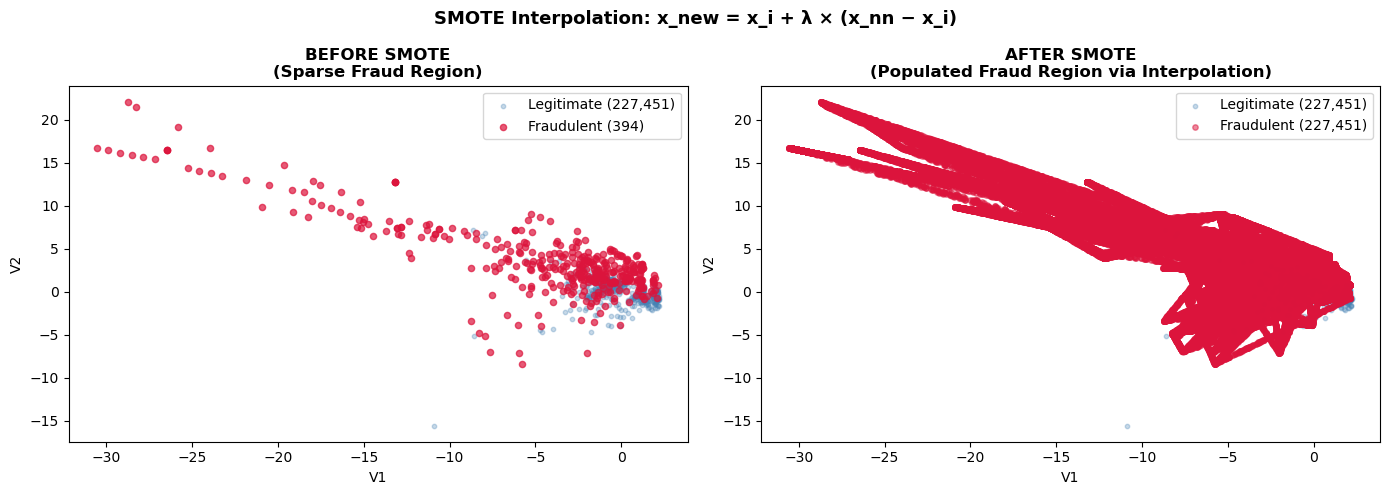

[SAVED] 05_smote_interpolation.png


In [56]:
#SMOTE effect
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before SMOTE
legit_before = X_train[y_train == 0][['V1','V2']].sample(500, random_state=42)
fraud_before = X_train[y_train == 1][['V1','V2']]
axes[0].scatter(legit_before['V1'], legit_before['V2'],
                alpha=0.3, s=10, color='steelblue', label=f'Legitimate ({(y_train==0).sum():,})')
axes[0].scatter(fraud_before['V1'], fraud_before['V2'],
                alpha=0.7, s=20, color='crimson', label=f'Fraudulent ({(y_train==1).sum():,})')
axes[0].set_title('BEFORE SMOTE\n(Sparse Fraud Region)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('V1')
axes[0].set_ylabel('V2')
axes[0].legend()

# After SMOTE
X_bal_df   = pd.DataFrame(X_train_bal, columns=X_train.columns)
legit_after = X_bal_df[y_train_bal == 0][['V1','V2']].sample(500, random_state=42)
fraud_after = X_bal_df[y_train_bal == 1][['V1','V2']]
axes[1].scatter(legit_after['V1'], legit_after['V2'],
                alpha=0.3, s=10, color='steelblue', label=f'Legitimate ({(y_train_bal==0).sum():,})')
axes[1].scatter(fraud_after['V1'], fraud_after['V2'],
                alpha=0.5, s=15, color='crimson', label=f'Fraudulent ({(y_train_bal==1).sum():,})')
axes[1].set_title('AFTER SMOTE\n(Populated Fraud Region via Interpolation)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('V1')
axes[1].set_ylabel('V2')
axes[1].legend()

plt.suptitle('SMOTE Interpolation: x_new = x_i + λ × (x_nn − x_i)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('05_smote_interpolation.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print("[SAVED] 05_smote_interpolation.png")

In [57]:
print("\n" + "=" * 60)
print("STEP 6: BUILDING IMBLEARN PIPELINES")
print("=" * 60)


STEP 6: BUILDING IMBLEARN PIPELINES


In [58]:
#Logistic Regression
lr_pipeline = Pipeline([
    ('scaler',     StandardScaler()),
    ('smote',      SMOTE(random_state=RANDOM_STATE)),
    ('classifier', LogisticRegression(
                       max_iter=1000,
                       random_state=RANDOM_STATE,
                       class_weight='balanced'))
])
print("\n[PIPELINE 1] Logistic Regression:")
print("  Step 1: StandardScaler  → Standardize (μ=0, σ=1)")
print("  Step 2: SMOTE           → Synthetic balancing on train fold only")
print("  Step 3: LogisticReg     → Gradient descent scoring (Linear boundary)")


[PIPELINE 1] Logistic Regression:
  Step 1: StandardScaler  → Standardize (μ=0, σ=1)
  Step 2: SMOTE           → Synthetic balancing on train fold only
  Step 3: LogisticReg     → Gradient descent scoring (Linear boundary)


In [59]:
#Random Forest
rf_pipeline = Pipeline([
    ('smote',      SMOTE(random_state=RANDOM_STATE)),
    ('classifier', RandomForestClassifier(
                       random_state=RANDOM_STATE,
                       n_jobs=-1,
                       class_weight='balanced'))
])
print("\n[PIPELINE 2] Random Forest:")
print("  Step 1: SMOTE           → Synthetic balancing on train fold only")
print("  Step 2: RandomForest    → Ensemble tree scoring (Non-linear boundary)")
print("  NOTE : No StandardScaler — tree models are scale-immune")


[PIPELINE 2] Random Forest:
  Step 1: SMOTE           → Synthetic balancing on train fold only
  Step 2: RandomForest    → Ensemble tree scoring (Non-linear boundary)
  NOTE : No StandardScaler — tree models are scale-immune


In [60]:
print("\n" + "=" * 60)
print("STEP 7: GRIDSEARCHCV HYPERPARAMETER TUNING")
print("=" * 60)


STEP 7: GRIDSEARCHCV HYPERPARAMETER TUNING


In [61]:
#Tune Logistic Regression
print("\n[TUNING] Logistic Regression — GridSearchCV (5-fold, scoring=roc_auc)")
lr_param_grid = {
    'smote__k_neighbors': [3, 5, 7],
    'classifier__C':      [0.01, 0.1, 1.0]
}
lr_grid = GridSearchCV(
    lr_pipeline,
    lr_param_grid,
    cv=CV_FOLDS,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1,
    refit=True
)
lr_grid.fit(X_train, y_train)
print(f"\n[LR] Best Params : {lr_grid.best_params_}")
print(f"[LR] Best ROC-AUC: {lr_grid.best_score_:.4f}")


[TUNING] Logistic Regression — GridSearchCV (5-fold, scoring=roc_auc)
Fitting 5 folds for each of 9 candidates, totalling 45 fits

[LR] Best Params : {'classifier__C': 0.01, 'smote__k_neighbors': 3}
[LR] Best ROC-AUC: 0.9804


In [62]:
#Tune Random Forest
print("\n[TUNING] Random Forest — GridSearchCV (5-fold, scoring=roc_auc)")
rf_param_grid = {
    'smote__k_neighbors':       [3, 5],
    'classifier__n_estimators': [100, 150],
    'classifier__max_depth':    [10, 20, None]
}
rf_grid = GridSearchCV(
    rf_pipeline,
    rf_param_grid,
    cv=CV_FOLDS,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1,
    
    refit=True
)
rf_grid.fit(X_train, y_train)
print(f"\n[RF] Best Params : {rf_grid.best_params_}")
print(f"[RF] Best ROC-AUC: {rf_grid.best_score_:.4f}")


[TUNING] Random Forest — GridSearchCV (5-fold, scoring=roc_auc)
Fitting 5 folds for each of 12 candidates, totalling 60 fits

[RF] Best Params : {'classifier__max_depth': 10, 'classifier__n_estimators': 150, 'smote__k_neighbors': 3}
[RF] Best ROC-AUC: 0.9839


In [63]:
lr_cv_results = pd.DataFrame(lr_grid.cv_results_)[
    ['param_smote__k_neighbors','param_classifier__C','mean_test_score']
].sort_values('mean_test_score', ascending=False).head(5)
print(f"\n[LR] Top 5 GridSearch Results:")
print(lr_cv_results.to_string(index=False))


[LR] Top 5 GridSearch Results:
 param_smote__k_neighbors  param_classifier__C  mean_test_score
                        3                 0.01         0.980366
                        7                 0.01         0.979963
                        5                 0.01         0.979774
                        3                 0.10         0.979455
                        3                 1.00         0.979287


In [64]:
print("\n" + "=" * 60)
print("STEP 8: FINAL EVALUATION ON TEST SET")
print("=" * 60)


STEP 8: FINAL EVALUATION ON TEST SET


In [65]:
def evaluate_model(name, model, X_test, y_test, color, file_prefix):
    print(f"\n{'─'*55}")
    print(f"  {name}")
    print(f"{'─'*55}")

    y_pred      = model.predict(X_test)
    y_pred_prob = model.predict_proba(X_test)[:, 1]

    print("\n[CLASSIFICATION REPORT] (The True Compass — NOT Accuracy)")
    report = classification_report(y_test, y_pred,
                                    target_names=['Legitimate','Fraudulent'])
    print(report)

    roc_auc = roc_auc_score(y_test, y_pred_prob)
    avg_prec = average_precision_score(y_test, y_pred_prob)
    print(f"[ROC-AUC Score]          : {roc_auc:.4f}  (target ≥ {ROC_AUC_TARGET})")
    print(f"[Avg Precision Score]    : {avg_prec:.4f}")
    status = "✓ PASSED" if roc_auc >= ROC_AUC_TARGET else "✗ BELOW TARGET"
    print(f"[ROC-AUC Target Check]   : {status}")

    #Optimal Threshold
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
    optimal_idx       = np.argmax(tpr - fpr)
    optimal_threshold = thresholds[optimal_idx]
    y_pred_optimal    = (y_pred_prob >= optimal_threshold).astype(int)
    print(f"\n[OPTIMAL THRESHOLD]      : {optimal_threshold:.4f}  (default was 0.5)")
    print("[REPORT WITH OPTIMAL THRESHOLD]")
    print(classification_report(y_test, y_pred_optimal,
                                 target_names=['Legitimate','Fraudulent']))

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    #Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=['Pred: Legit','Pred: Fraud'],
                yticklabels=['Actual: Legit','Actual: Fraud'])
    tn, fp, fn, tp = cm.ravel()
    axes[0].set_title(f'Confusion Matrix\nTP={tp} | FP={fp} | FN={fn} | TN={tn:,}',
                      fontsize=11, fontweight='bold')

    #ROC Curve
    axes[1].plot(fpr, tpr, color=color, lw=2,
                 label=f'ROC-AUC = {roc_auc:.4f}')
    axes[1].plot([0,1],[0,1],'k--', lw=1, label='Random Classifier (0.5)')
    axes[1].axhline(y=tpr[optimal_idx], color='gray', linestyle=':',
                    alpha=0.7, label=f'Optimal threshold = {optimal_threshold:.3f}')
    axes[1].axvline(x=fpr[optimal_idx], color='gray', linestyle=':', alpha=0.7)
    axes[1].scatter([fpr[optimal_idx]], [tpr[optimal_idx]],
                    color='gold', s=100, zorder=5, label='Optimal point')
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate (Recall)')
    axes[1].set_title(f'ROC Curve\nTarget: {ROC_AUC_TARGET}+', fontsize=11, fontweight='bold')
    axes[1].legend(fontsize=9)
    axes[1].fill_between(fpr, tpr, alpha=0.1, color=color)

    #Precision-Recall Curve
    precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_pred_prob)
    axes[2].plot(recall_vals, precision_vals, color=color, lw=2,
                 label=f'Avg Precision = {avg_prec:.4f}')
    axes[2].axhline(y=pct_fraud/100, color='gray', linestyle='--',
                    label=f'Baseline ({pct_fraud:.2f}%)')
    axes[2].set_xlabel('Recall — Did we catch all fraud?')
    axes[2].set_ylabel('Precision — When we flag fraud, are we right?')
    axes[2].set_title('Precision-Recall Curve\n(The True Compass)', fontsize=11, fontweight='bold')
    axes[2].legend(fontsize=9)
    axes[2].fill_between(recall_vals, precision_vals, alpha=0.1, color=color)

    plt.suptitle(f'{name} — Complete Evaluation Dashboard',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{file_prefix}_evaluation.png', dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f"[SAVED] {file_prefix}_evaluation.png")

    return roc_auc, avg_prec, optimal_threshold


───────────────────────────────────────────────────────
  Logistic Regression
───────────────────────────────────────────────────────

[CLASSIFICATION REPORT] (The True Compass — NOT Accuracy)
              precision    recall  f1-score   support

  Legitimate       1.00      0.97      0.99     56864
  Fraudulent       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962

[ROC-AUC Score]          : 0.9719  (target ≥ 0.85)
[Avg Precision Score]    : 0.7180
[ROC-AUC Target Check]   : ✓ PASSED

[OPTIMAL THRESHOLD]      : 0.6228  (default was 0.5)
[REPORT WITH OPTIMAL THRESHOLD]
              precision    recall  f1-score   support

  Legitimate       1.00      0.98      0.99     56864
  Fraudulent       0.08      0.92      0.16        98

    accuracy                           0.98     56962
   macro avg       0.54      0.95      0.57     56962


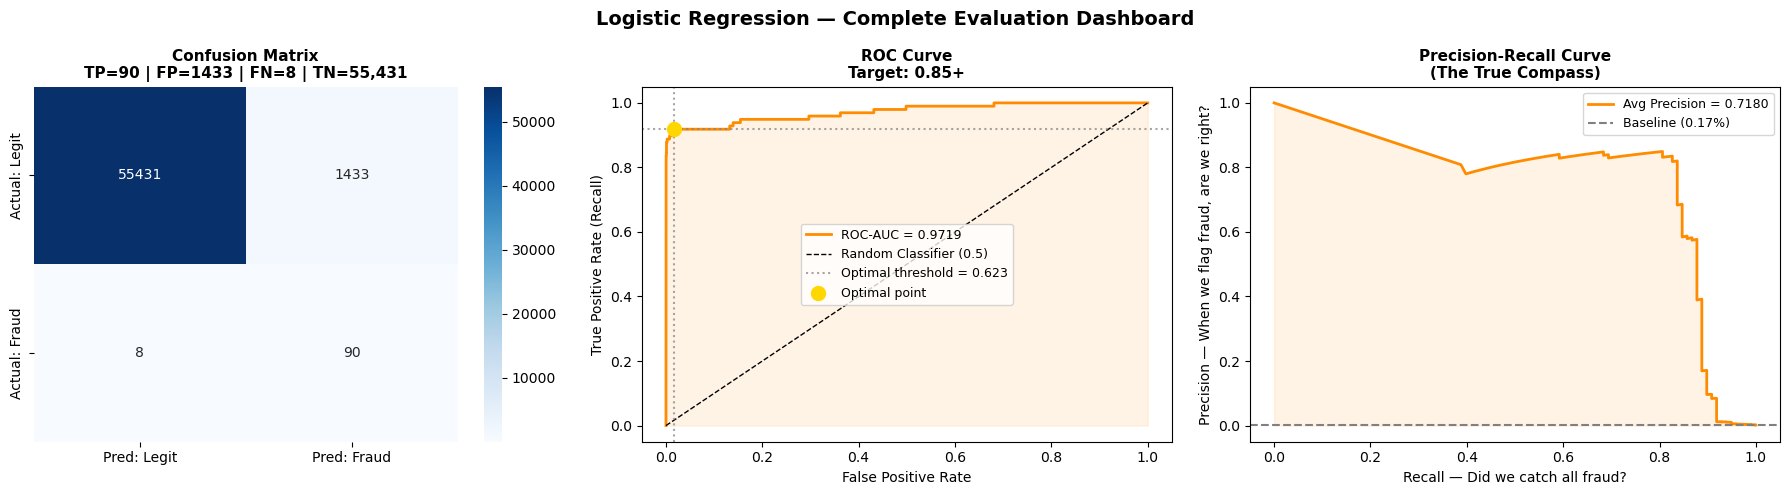

[SAVED] 06_logistic_regression_evaluation.png


In [66]:
# Evaluate Logistic Regression
lr_roc, lr_ap, lr_thresh = evaluate_model(
    "Logistic Regression",
    lr_grid.best_estimator_,
    X_test, y_test,
    color='darkorange',
    file_prefix='06_logistic_regression'
)


───────────────────────────────────────────────────────
  Random Forest
───────────────────────────────────────────────────────

[CLASSIFICATION REPORT] (The True Compass — NOT Accuracy)
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
  Fraudulent       0.54      0.88      0.67        98

    accuracy                           1.00     56962
   macro avg       0.77      0.94      0.84     56962
weighted avg       1.00      1.00      1.00     56962

[ROC-AUC Score]          : 0.9822  (target ≥ 0.85)
[Avg Precision Score]    : 0.8115
[ROC-AUC Target Check]   : ✓ PASSED

[OPTIMAL THRESHOLD]      : 0.2965  (default was 0.5)
[REPORT WITH OPTIMAL THRESHOLD]
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
  Fraudulent       0.26      0.91      0.41        98

    accuracy                           1.00     56962
   macro avg       0.63      0.95      0.70     56962
weight

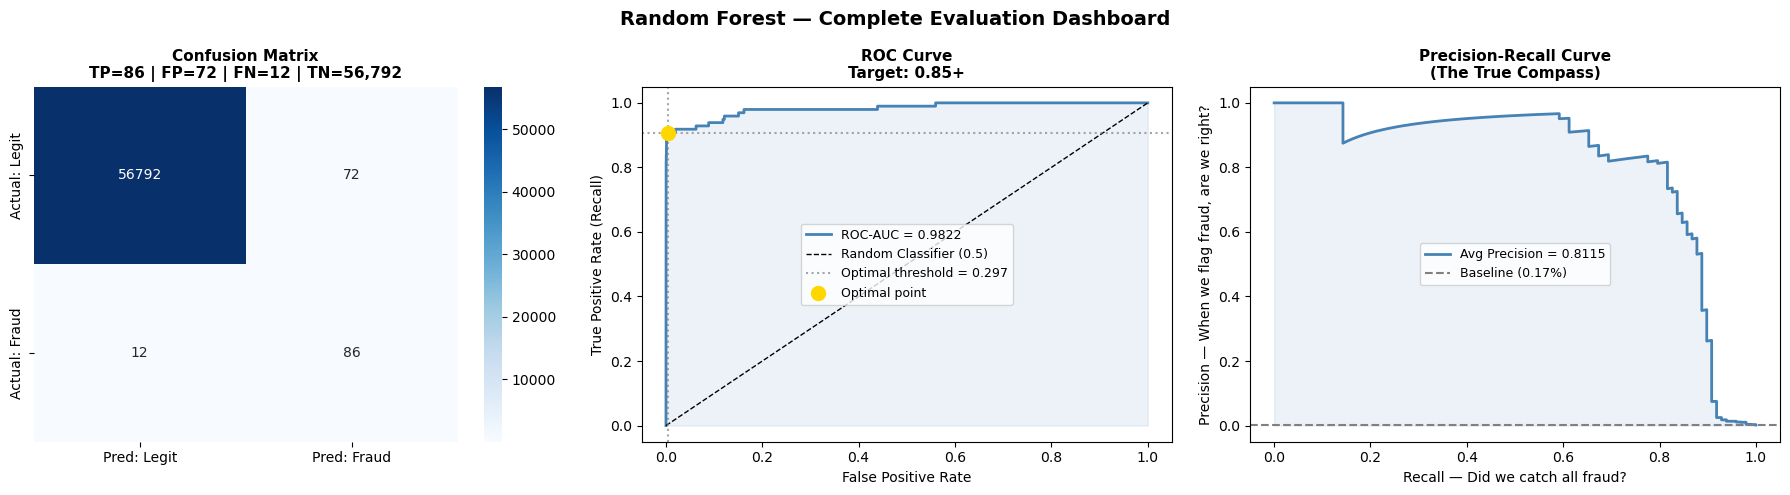

[SAVED] 07_random_forest_evaluation.png


In [67]:
# Evaluate Random Forest
rf_roc, rf_ap, rf_thresh = evaluate_model(
    "Random Forest",
    rf_grid.best_estimator_,
    X_test, y_test,
    color='steelblue',
    file_prefix='07_random_forest'
)

In [68]:
print("\n" + "=" * 60)
print("STEP 9: FEATURE IMPORTANCE (Random Forest)")
print("=" * 60)


STEP 9: FEATURE IMPORTANCE (Random Forest)


In [69]:
rf_best       = rf_grid.best_estimator_
rf_classifier = rf_best.named_steps['classifier']
importances   = rf_classifier.feature_importances_
feat_names    = X_train.columns.tolist()

feat_df = pd.DataFrame({
    'Feature':    feat_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print("\n[TOP 15 MOST IMPORTANT FEATURES]")
print(feat_df.head(15).to_string(index=False))


[TOP 15 MOST IMPORTANT FEATURES]
Feature  Importance
    V14    0.221125
    V10    0.152256
    V12    0.117233
     V4    0.115142
    V17    0.081240
     V3    0.072013
    V11    0.045215
    V16    0.040457
     V2    0.031015
     V7    0.021326
     V9    0.020421
    V21    0.013834
     V1    0.006984
     V6    0.005966
    V18    0.005854


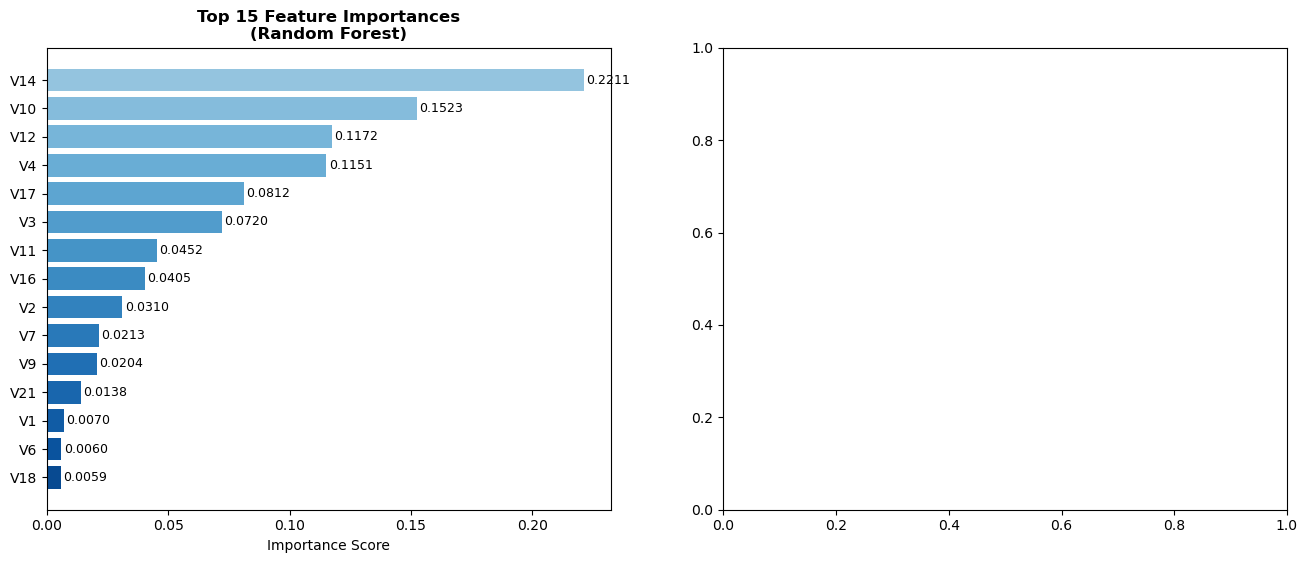

In [70]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 15 features bar chart
top15 = feat_df.head(15)
colors_imp = plt.cm.Blues(np.linspace(0.4, 0.9, 15))[::-1]
axes[0].barh(top15['Feature'][::-1], top15['Importance'][::-1],
             color=colors_imp)
axes[0].set_title('Top 15 Feature Importances\n(Random Forest)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Importance Score')
for i, (feat, imp) in enumerate(zip(top15['Feature'][::-1], top15['Importance'][::-1])):
    axes[0].text(imp + 0.001, i, f'{imp:.4f}', va='center', fontsize=9)

In [71]:
# Cumulative importance
cumulative = feat_df['Importance'].cumsum()
axes[1].plot(range(1, len(cumulative)+1), cumulative,
             color='steelblue', lw=2, marker='o', markersize=3)
axes[1].axhline(y=0.80, color='orange', linestyle='--', label='80% threshold')
axes[1].axhline(y=0.95, color='red',    linestyle='--', label='95% threshold')
axes[1].set_title('Cumulative Feature Importance', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Number of Features')
axes[1].set_ylabel('Cumulative Importance')
axes[1].legend()
axes[1].set_xlim(1, len(cumulative))
axes[1].set_ylim(0, 1.05)

n80 = (cumulative < 0.80).sum() + 1
n95 = (cumulative < 0.95).sum() + 1
print(f"\n[INFO] Features needed for 80% importance: {n80}")
print(f"[INFO] Features needed for 95% importance: {n95}")

plt.suptitle('Random Forest — Feature Importance Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('08_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print("[SAVED] 08_feature_importance.png")


[INFO] Features needed for 80% importance: 7
[INFO] Features needed for 95% importance: 15


<Figure size 640x480 with 0 Axes>

[SAVED] 08_feature_importance.png


In [72]:
print("\n" + "=" * 60)
print("STEP 10: FINAL MODEL COMPARISON")
print("=" * 60)


STEP 10: FINAL MODEL COMPARISON


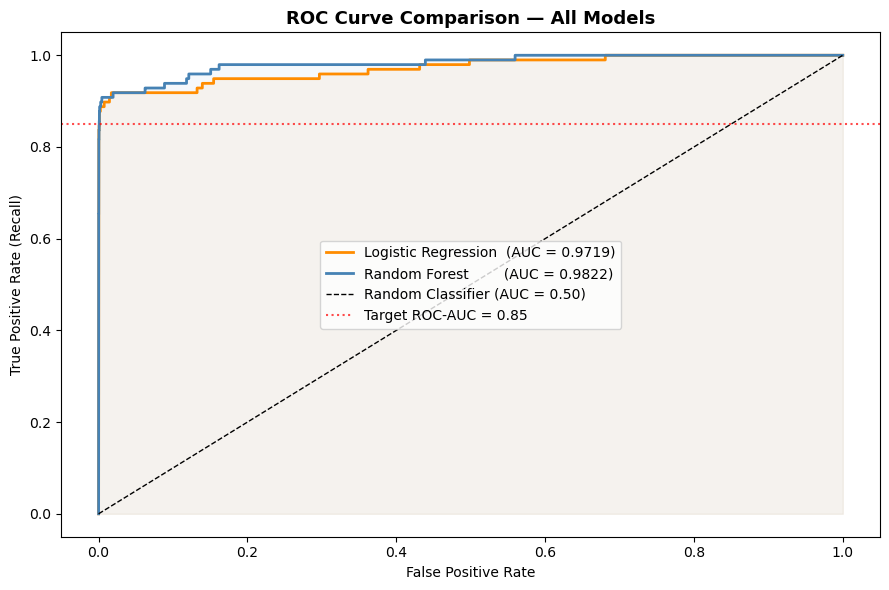

[SAVED] 09_roc_comparison.png


In [73]:
# Side-by-side ROC curves
fpr_lr, tpr_lr, _ = roc_curve(y_test,
    lr_grid.best_estimator_.predict_proba(X_test)[:,1])
fpr_rf, tpr_rf, _ = roc_curve(y_test,
    rf_grid.best_estimator_.predict_proba(X_test)[:,1])

plt.figure(figsize=(9, 6))
plt.plot(fpr_lr, tpr_lr, color='darkorange', lw=2,
         label=f'Logistic Regression  (AUC = {lr_roc:.4f})')
plt.plot(fpr_rf, tpr_rf, color='steelblue',  lw=2,
         label=f'Random Forest        (AUC = {rf_roc:.4f})')
plt.plot([0,1],[0,1], 'k--', lw=1, label='Random Classifier (AUC = 0.50)')
plt.axhline(y=ROC_AUC_TARGET, color='red', linestyle=':',
            alpha=0.7, label=f'Target ROC-AUC = {ROC_AUC_TARGET}')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve Comparison — All Models', fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.fill_between(fpr_rf, tpr_rf, alpha=0.05, color='steelblue')
plt.fill_between(fpr_lr, tpr_lr, alpha=0.05, color='darkorange')
plt.tight_layout()
plt.savefig('09_roc_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print("[SAVED] 09_roc_comparison.png")

In [74]:
# ── Final Summary Report ──
print("\n" + "=" * 60)
print("  FINAL PIPELINE REPORT — ZERO LEAKAGE PROTOCOL")
print("=" * 60)


  FINAL PIPELINE REPORT — ZERO LEAKAGE PROTOCOL


In [75]:
winner     = "Random Forest" if rf_roc > lr_roc else "Logistic Regression"
winner_roc = max(rf_roc, lr_roc)

print(f"""
  DATASET
  ├─ Total transactions   : {len(df):,}
  ├─ Legitimate           : {n_legit:,}  ({pct_legit:.2f}%)
  └─ Fraudulent           : {n_fraud:,}  ({pct_fraud:.2f}%)

  SPLIT (Stratified — BEFORE SMOTE)
  ├─ Train set            : {len(X_train):,} rows
  └─ Test set             : {len(X_test):,} rows

  SMOTE
  ├─ Applied inside pipeline only (no leakage)
  ├─ Formula              : x_new = x_i + λ × (x_nn − x_i)
  └─ Synthetic fraud rows : {y_train_bal.sum() - y_train.sum():,}

  MODEL RESULTS
  ├─ Logistic Regression  ROC-AUC: {lr_roc:.4f}  {'✓ PASSED' if lr_roc >= ROC_AUC_TARGET else '✗ BELOW TARGET'}
  ├─ Random Forest        ROC-AUC: {rf_roc:.4f}  {'✓ PASSED' if rf_roc >= ROC_AUC_TARGET else '✗ BELOW TARGET'}
  └─ WINNER               : {winner}  (AUC = {winner_roc:.4f})

  OPTIMAL THRESHOLDS
  ├─ Logistic Regression  : {lr_thresh:.4f}  (default was 0.5)
  └─ Random Forest        : {rf_thresh:.4f}  (default was 0.5)

  ZERO-LEAKAGE PROTOCOL
  ├─ ✓ Split BEFORE SMOTE
  ├─ ✓ Used imblearn.pipeline.Pipeline
  ├─ ✓ StandardScaler inside LR pipeline only
  ├─ ✓ SMOTE applied only on training folds in GridSearchCV
  ├─ ✓ Test set never exposed to SMOTE or Scaler
  └─ ✓ Optimized on ROC-AUC, not Accuracy

  OUTPUT FILES SAVED
  ├─ 01_class_imbalance.png
  ├─ 02_amount_distribution.png
  ├─ 03_accuracy_trap.png
  ├─ 04_rebalancing_comparison.png
  ├─ 05_smote_interpolation.png
  ├─ 06_logistic_regression_evaluation.png
  ├─ 07_random_forest_evaluation.png
  ├─ 08_feature_importance.png
  └─ 09_roc_comparison.png
""")


  DATASET
  ├─ Total transactions   : 284,807
  ├─ Legitimate           : 284,315  (99.83%)
  └─ Fraudulent           : 492  (0.17%)

  SPLIT (Stratified — BEFORE SMOTE)
  ├─ Train set            : 227,845 rows
  └─ Test set             : 56,962 rows

  SMOTE
  ├─ Applied inside pipeline only (no leakage)
  ├─ Formula              : x_new = x_i + λ × (x_nn − x_i)
  └─ Synthetic fraud rows : 227,057

  MODEL RESULTS
  ├─ Logistic Regression  ROC-AUC: 0.9719  ✓ PASSED
  ├─ Random Forest        ROC-AUC: 0.9822  ✓ PASSED
  └─ WINNER               : Random Forest  (AUC = 0.9822)

  OPTIMAL THRESHOLDS
  ├─ Logistic Regression  : 0.6228  (default was 0.5)
  └─ Random Forest        : 0.2965  (default was 0.5)

  ZERO-LEAKAGE PROTOCOL
  ├─ ✓ Split BEFORE SMOTE
  ├─ ✓ Used imblearn.pipeline.Pipeline
  ├─ ✓ StandardScaler inside LR pipeline only
  ├─ ✓ SMOTE applied only on training folds in GridSearchCV
  ├─ ✓ Test set never exposed to SMOTE or Scaler
  └─ ✓ Optimized on ROC-AUC, not Accuracy

